# Exercise: Linear Algebra and NumPy

---

## Introduction

In this exercise, we will learn how to use the NumPy library and review basic linear algebra concepts.

The exercise consists of four main parts:

- **Exercise 1 — Cosine Similarity**
- **Exercise 2 — Grayscale Conversion**
- **Exercise 3 — Background Subtraction**
- **Exercise 4 — Tabular Data Analysis**


### Exercise 1 - Cosine Similarity

#### 1. Length of a vector

- Vector: $v = [v_1, v_2, \ldots, v_n]^T$
- Length of a vector:
$$
\| v \| = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2}
$$


In [21]:
import numpy as np

def compute_vector_length(vector):
    length = 0
    length = np.power(vector, 2)
    length = np.sum(length)
    #length2 = np.sqrt(np.sum(np.power(vector, 2)))  #compact
    return np.sqrt(length)


In [22]:
vector = np.array([4, -2, 5, 12])
length = compute_vector_length(vector)
print(length)

13.74772708486752


#### 2. Dot product

- Vectors:
$$
v = \begin{pmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{pmatrix}
\qquad
u = \begin{pmatrix} u_1 \\ u_2 \\ \vdots \\ u_n \end{pmatrix}
$$
- Dot product:
$$
v \cdot u = v_1 u_1 + v_2 u_2 + \cdots + v_n u_n
$$


In [23]:
def compute_dot_product(vector1, vector2):
    dot_product = np.dot(vector1, vector2)
    return dot_product

In [24]:
vec1 = np.array([1, 1, -1, 3])
vec2 = np.array([1, 2, 3, 4])
dot_product = compute_dot_product(vec1, vec2)
print(dot_product)

12


#### 3. Cosine similarity

- Data (vectors $x$, $y$): $x = \{x_1, \ldots, x_N\}$, $y = \{y_1, \ldots, y_N\}$
- Cosine similarity:
$$
cs(x, y) = \frac{x \cdot y}{\| x \| \, \| y \|} = \frac{\sum_{i=1}^{n} x_i y_i}{\sqrt{\sum_{i=1}^{n} x_i^2} \sqrt{\sum_{i=1}^{n} y_i^2}}
$$


In [25]:
def compute_cosisne(vector1, vector2):
    numerator = np.sum(compute_dot_product(vector1, vector2))
    denominator = np.sqrt(np.sum(np.power(vector1, 2))) * np.sqrt(np.sum(np.power(vector2, 2)))
    return numerator / denominator


In [26]:
vec1 = np.array([1, 1, -1, 3])
vec2 = np.array([1, 2, 3, 4])
cos_sim = compute_cosisne(vec1, vec2)
print(cos_sim)

0.6324555320336759


#### 5. Cosine similarity using a built-in library (scipy)

Verify the result using the built-in function in scipy. Note that `scipy.spatial.distance.cosine` returns the **cosine distance**, i.e. $1 - \text{cosine similarity}$.


In [27]:
from scipy.spatial.distance import cosine

def compute_cosine_scipy(vector1, vector2):
    temp = cosine(vector1, vector2)
    cos_sim = 1 - temp
    return cos_sim

##### Test zu confirm whether two calculation are the same

In [28]:
cos_sim_scipy = compute_cosine_scipy(vec1, vec2)
print("cosine similarity with scipy: ", cos_sim_scipy)
print("cosine similarity with numpy: ", cos_sim)

cosine similarity with scipy:  0.6324555320336759
cosine similarity with numpy:  0.6324555320336759


### Exercise 2 - Grayscale Conversion

A color image is typically represented using three channels: red, green, and blue (RGB). In this section, we will convert a color image to grayscale using four different methods — the first three implemented manually, and the last one using the OpenCV library.

**Grayscale conversion formulas:**

- Lightness:
$$
gray = \frac{\max(R, G, B) + \min(R, G, B)}{2}
$$
- Average:
$$
gray = \frac{R + G + B}{3}
$$
- Luminosity:
$$
gray = 0.21 \times R + 0.72 \times G + 0.07 \times B
$$


In [29]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

def show_image(image, title=""):
    plt.imshow(image,cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

(300, 300, 3)


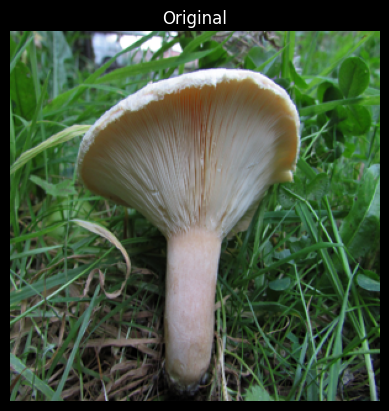

In [30]:
image = mpimg.imread("mushroom.png")
print(image.shape)
show_image(image, "Original")

#### 1. Lightness method:
$$
\frac{\max(R, G, B) + \min(R, G, B)}{2}
$$


In [31]:
def to_gray_lightness(image):
    r, g, b = image[:, :, 0], image[:, :, 1], image[:, :, 2]
    gray_image = (np.maximum(r,g,b)+np.minimum(r,g,b)) / 2
    return gray_image

0.34901962


C:\Users\minhn\AppData\Local\Temp\ipykernel_23636\3421401880.py:3: DeprecationWarning: Passing more than 2 positional arguments to np.maximum and np.minimum is deprecated. If you meant to use the third argument as an output, use the `out` keyword argument instead. If you hoped to work with more than 2 inputs, combine them into a single array and get the extrema for the relevant axis.
  gray_image = (np.maximum(r,g,b)+np.minimum(r,g,b)) / 2


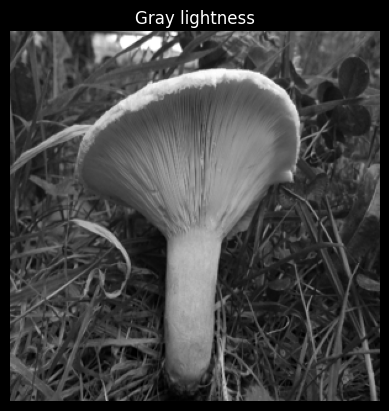

In [32]:
gray_image_lightness = to_gray_lightness(image)
print(gray_image_lightness[0, 0])
show_image(gray_image_lightness, "Gray lightness")

#### **2. Average method:**
$$
\frac{R + G + B}{3}
$$


In [33]:
def to_gray_average(image):
    r, g, b = image[:, :, 0], image[:, :, 1], image[:, :, 2]
    gray_image = (r + g + b) / 3
    return gray_image

0.40653598


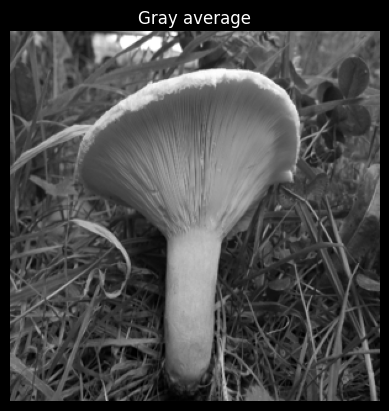

In [34]:
gray_image_average = to_gray_average(image)
print(gray_image_average[0, 0])
show_image(gray_image_average, "Gray average")

#### **3. Luminosity method:**
$$
0.21 \times R + 0.72 \times G + 0.07 \times B
$$


In [35]:
def to_gray_luminosity(image):
    r, g, b = image[:, :, 0], image[:, :, 1], image[:, :, 2]
    gray_image = 0.21 * r + 0.72 * g + 0.07 * b
    return gray_image

0.47325495


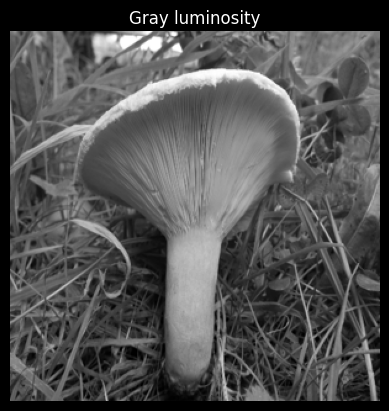

In [36]:
gray_image_luminosity = to_gray_luminosity(image)
print(gray_image_luminosity[0, 0])
show_image(gray_image_luminosity, "Gray luminosity")

In [37]:
# show_image(image, "Original")
# show_image(gray_image_lightness, "Gray lightness")
# show_image(gray_image_average, "Gray average")
# show_image(gray_image_luminosity, "Gray luminosity")

#### **4. Using a built-in library (`cv2.cvtColor`):** Compare the result with OpenCV's built-in function.

In [38]:
import cv2
def to_gray_cv2(image):
    gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return gray_img

0.4503059


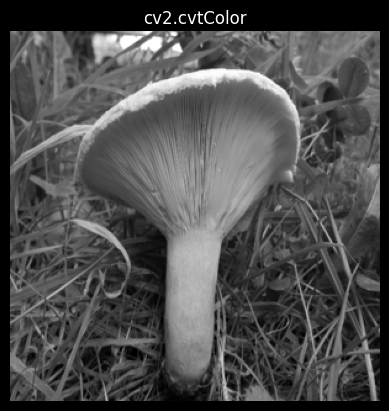

In [39]:
gray_img_cv2 = to_gray_cv2(image)
print(gray_img_cv2[0, 0])
show_image(gray_img_cv2, "cv2.cvtColor")

### 2.3. Background Subtraction

In [40]:
def show_image(img, title=""):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


IMG_SIZE = (678, 381)
bg_image = cv2.resize(cv2.imread("background.jpg"), IMG_SIZE)
ob_image = cv2.resize(cv2.imread("Object2.jpg"), IMG_SIZE)

print(bg_image.shape, ob_image.shape)


(381, 678, 3) (381, 678, 3)


In [41]:
def grabcut_mask(img, rect):
    mask = np.zeros(img.shape[:2], np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    cv2.grabCut(img, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

    # 0/2 = background, 1/3 = foreground
    binary_mask = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8") * 255
    return binary_mask

In [42]:
def replace_background(ob_image, bg2_image, rect):
    binary_mask = grabcut_mask(ob_image, rect)

    # Maske auf 3 Kanäle erweitern, damit sie zur Farbtiefe der Bilder passt
    binary_mask_3ch = cv2.merge([binary_mask, binary_mask, binary_mask])

    # Wo Maske = 255 -> Objekt behalten, sonst -> neuer Hintergrund
    output = np.where(binary_mask_3ch == 255, ob_image, bg2_image)

    return output.astype(np.uint8)

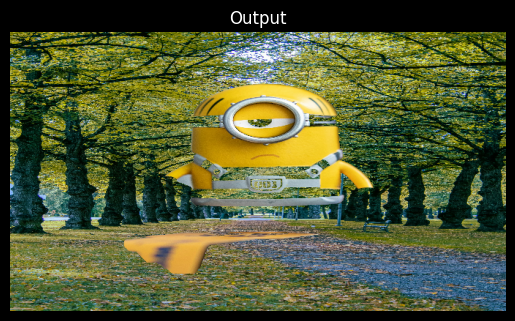

In [43]:
rect = (150, 30, 400, 300)  # grobe Box um das Objekt anpassen
output = replace_background(ob_image, bg_image, rect)
show_image(output, "Output")